In [1]:
using Pkg
Pkg.activate(joinpath(@__FILE__, "..", ".."))
Pkg.instantiate()
using Revise
import HybridDynamics as HD
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
Precompiling packages...
    578.1 ms  ? HybridDynamics

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


In [2]:
A = [0.0 1.0; -1.0 0.0]
λ = [1.0, 0.0]
a = -1.0 
C = [-1.0 0.0 ; 0.0 1.0] 
x0 = [0.0, 5.0]
tspan = (0.0, 5.0)
b = [0.0, 0.0]
κ = [0.0, 0.0]

2-element Vector{Float64}:
 0.0
 0.0

In [3]:
#Putting NaNs when jumps occur to prevent Plots from drawing continuous lines. 
function get_rid_of_jump_lines(sol)
    x1 = Float64[]
    x2 = Float64[]

    for i in 1:length(sol.x)
        push!(x1, sol.x[i][1])
        push!(x2, sol.x[i][2])
        # If the time doesn't advance, a jump occurred
        if i < length(sol.t) && sol.t[i] == sol.t[i+1]
            push!(x1, NaN)
            push!(x2, NaN)
        end
    end
    return x1, x2
end

get_rid_of_jump_lines (generic function with 1 method)

In [ ]:
function add_guard!(p, λ, a=0.0)
    if abs(λ[2]) < 1e-10
        # If λ[2] is 0, it's a vertical line at x1 = -a/λ[1]
        plt.vline!(p, [-a / λ[1]], label="Guard (λᵀx + a = 0)", color=:black, alpha=0.3, linewidth=2)
    else
        # Otherwise, calculate x2 as a function of x1 using plot bounds
        xl = plt.xlims(p)
        x_vals = [xl[1], xl[2]]
        y_vals = @. (-a - λ[1] * x_vals) / λ[2]
        plt.plot!(p, x_vals, y_vals, label="Guard", color=:black, alpha=0.3, linewidth=2)
        plt.xlims!(p, xl) # Lock the limits so the guard doesn't stretch the plot
    end
end;

Solving Affine System...


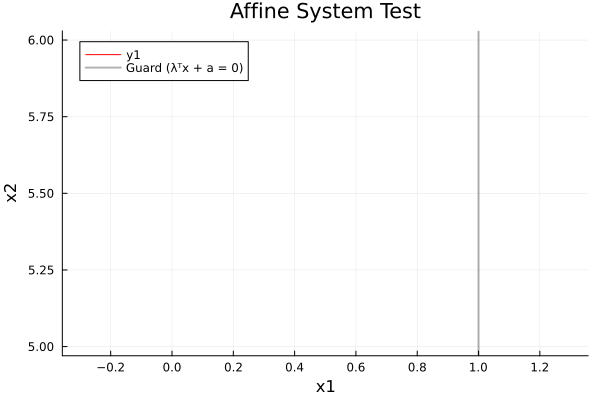

┌ Warning: Maximum Iteration Count (1000000) reached.
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Linear_Affine.jl:408


In [ ]:
# Build and Solve
sys_affine = HD.AffineSystem(A, b, λ, a, C, κ)
prob_affine = HD.prob(sys_affine, x0, tspan)

println("Solving Affine System...")
sol_affine = HD.solve(prob_affine, HD.RK4(); event_method = HD.LinearLocator())

# Plot trajectories
p_affine = plt.plot(title="Affine System Test", xlabel="x1", ylabel="x2", grid=true, aspect_ratio=:equal)

x1_aff, x2_aff = get_rid_of_jump_lines(sol_affine)
plt.plot!(p_affine, x1_aff, x2_aff, color=:red)

#add the guard based on Cell 1's λ and Cell 2's a
add_guard!(p_affine, λ, a)

plt.display(p_affine)

In [ ]:
# Build system using shared parameters
sys_linear = HD.LinearSystem(A, λ, C)
prob_linear = HD.prob(sys_linear, x0, tspan)

println("Solving Linear System...")

# Compare Solvers
sol_linear = HD.solve(prob_linear, HD.RK4())

# Plot trajectories
p_linear = plt.plot(title="Linear System", xlabel="x1", ylabel="x2", aspect_ratio=:equal)

x1_linear, x2_linear = get_rid_of_jump_lines(sol_linear)
plt.plot!(p_linear, x1_linear, x2_linear, color=:red)

# Dynamically add the guard based input
add_guard!(p_linear, λ, 0.0)

display(p_linear)

Solving Linear System...


┌ Info: Zeno contraction detected. zeno_count: 1
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 2
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 3
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 4
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 5
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 6
└ @ HybridDynamics c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. zeno_count: 7
└ @ HybridDynamics c:\Users\david\Desktop\Program\V

In [ ]:
println("Time | State AFFINE")
for i in 1:length(sol_affine.t)
    println(sol_affine.t[i], " | ", sol_affine.x[i])
end

In [ ]:
println("Time | State LINEAR")
for i in 1:length(sol_linear.t)
    println(sol_linear.t[i], " | ", sol_linear.x[i])
end